# 08 Visuals

## Objective
Create final presentation-ready charts for the report, GitHub repository, and dashboard support materials.

## Inputs
- `data/processed/station_metrics.csv`
- `data/processed/failure_results.csv`
- `data/processed/top_station_risk_scores.csv`
- performance summary CSVs

## Outputs
- PNG charts in the `outputs/` folder
- `data/processed/final_station_table.csv`

## Why this step matters
This notebook converts final analytical outputs into portfolio-ready visuals that communicate the results clearly.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
BASE_DIR = Path("..")
PROCESSED_DIR = BASE_DIR / "data" / "processed"
OUTPUTS_DIR = BASE_DIR / "outputs"

In [4]:
station_metrics = pd.read_csv(PROCESSED_DIR / "station_metrics.csv")
failure_results = pd.read_csv(PROCESSED_DIR / "failure_results.csv")
risk_scores = pd.read_csv(PROCESSED_DIR / "top_station_risk_scores.csv")

service_line_summary = pd.read_csv(PROCESSED_DIR / "service_line_summary.csv")
km_line_summary = pd.read_csv(PROCESSED_DIR / "km_line_summary.csv")
km_comparison_summary = pd.read_csv(PROCESSED_DIR / "km_comparison_summary.csv")
ejt_line_summary = pd.read_csv(PROCESSED_DIR / "ejt_line_summary.csv")

print("Files loaded successfully")

Files loaded successfully


In [5]:
risk_scores.head()

,station_removed,num_components,largest_component_size,avg_shortest_path,components_norm,largest_component_loss,largest_component_loss_norm,avg_shortest_path_norm,failure_impact_score,station_display,station,degree_centrality,betweenness_centrality,closeness_centrality,betweenness_norm,degree_norm,closeness_norm,propagation_risk_score
0,baker street,1,271,17.167910,0.0,0,0.000000,1.000000,0.300000,Baker Street,baker street,0.02583,0.354381,0.114394,1.000000,1.000000,0.950907,0.790000
1,green park,1,271,14.429684,0.0,0,0.000000,0.291126,0.087338,Green Park,green park,0.02214,0.341879,0.118186,0.964722,0.833333,1.000000,0.675229
2,earls court,3,262,14.673101,1.0,9,0.409091,0.354142,0.628970,Earls Court,earls court,0.02214,0.205972,0.092904,0.581216,0.833333,0.672642,0.645965
3,kings cross st. pancras,2,254,14.127852,0.5,17,0.772727,0.212987,0.495714,Kings Cross St. Pancras,kings cross st. pancras,0.02583,0.195583,0.106108,0.551900,1.000000,0.843615,0.624664
4,waterloo,1,271,14.540823,0.0,0,0.000000,0.319897,0.095969,Waterloo,waterloo,0.02214,0.282364,0.108792,0.796781,0.833333,0.878363,0.593848


## Step 1: Create station-risk visuals

These charts highlight the most structurally critical and failure-sensitive stations.

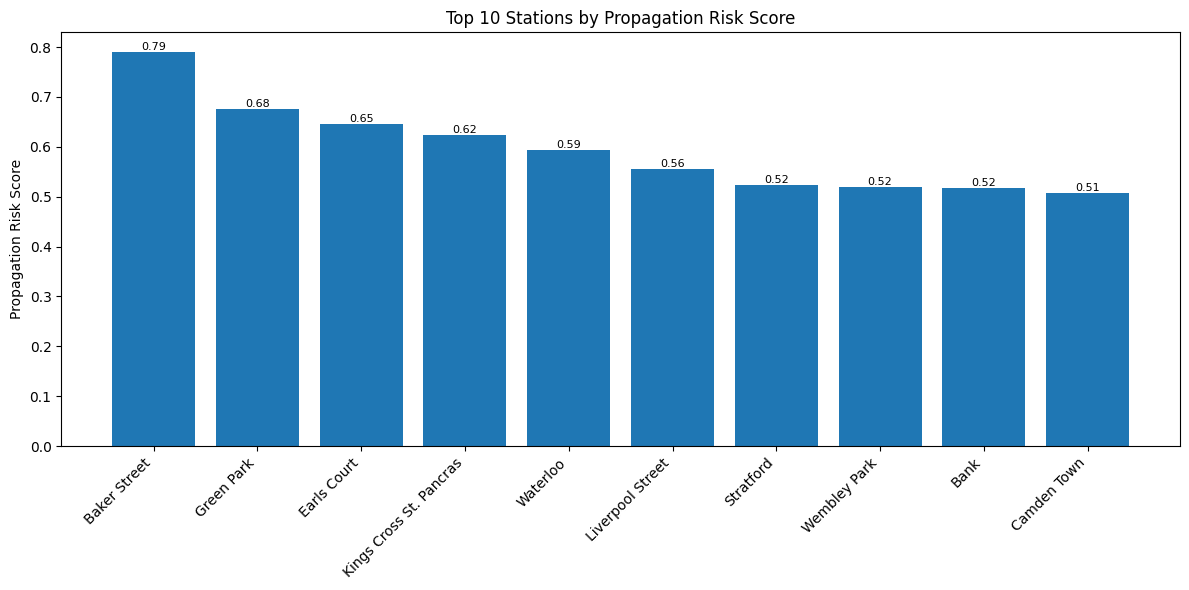

In [6]:
top10_risk = risk_scores.sort_values("propagation_risk_score", ascending=False).head(10)

plt.figure(figsize=(12, 6))
bars = plt.bar(top10_risk["station_display"], top10_risk["propagation_risk_score"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Propagation Risk Score")
plt.title("Top 10 Stations by Propagation Risk Score")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "top_10_propagation_risk_stations.png")
plt.show()

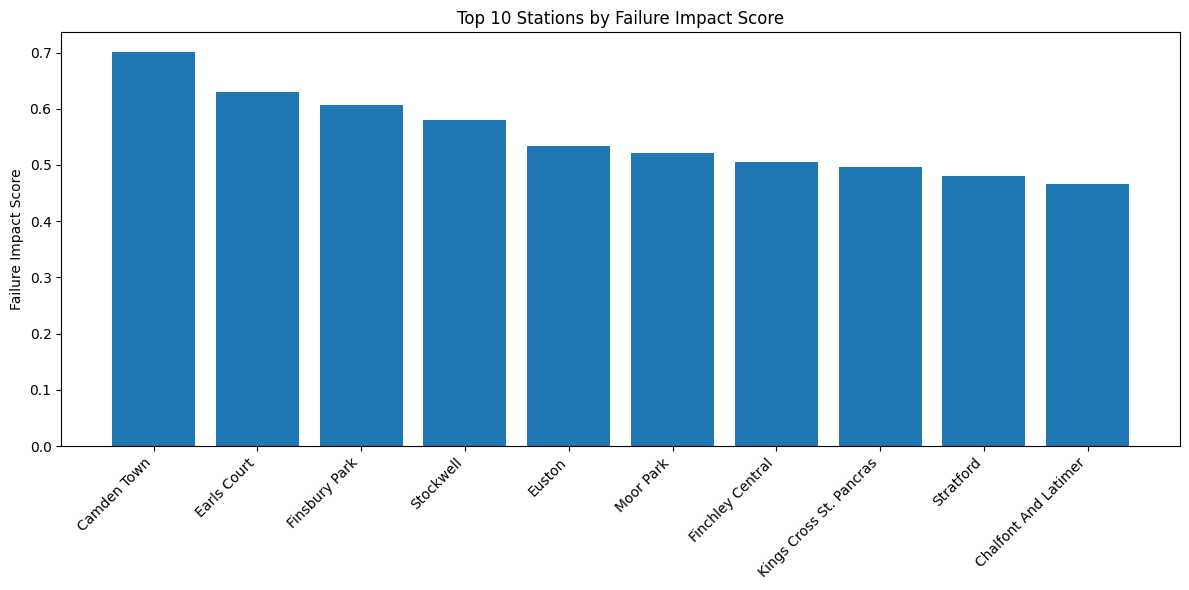

In [7]:
top10_failure = failure_results.sort_values("failure_impact_score", ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.bar(top10_failure["station_display"], top10_failure["failure_impact_score"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Failure Impact Score")
plt.title("Top 10 Stations by Failure Impact Score")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "top_10_failure_impact_stations.png")
plt.show()

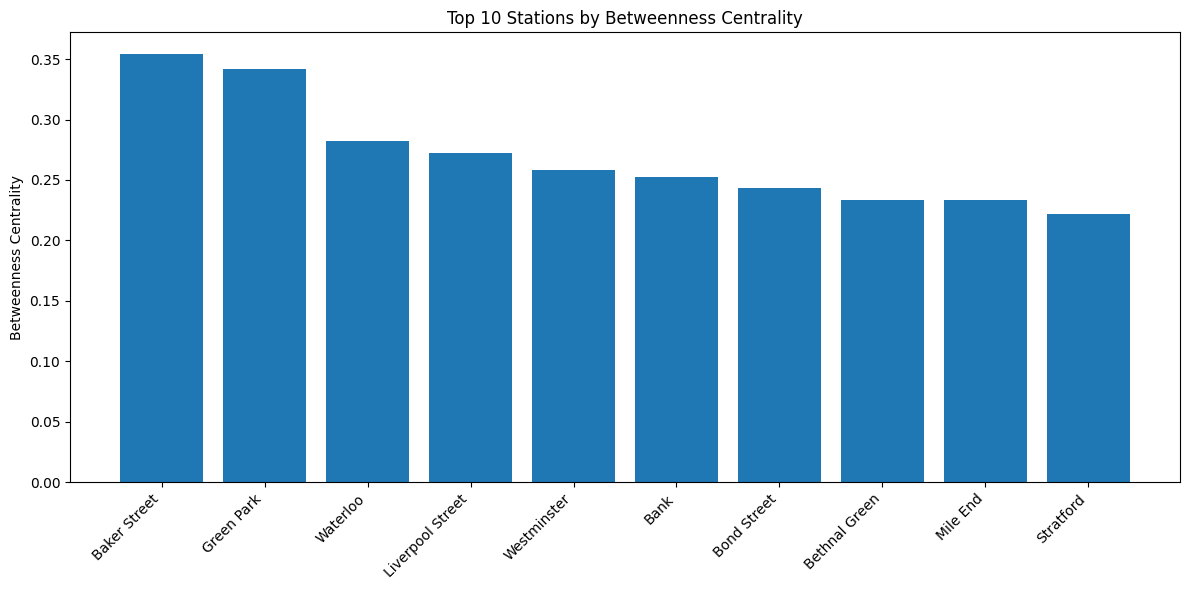

In [8]:
station_metrics["station_display"] = (
    station_metrics["station"]
    .astype(str)
    .str.replace(" underground", "", regex=False)
    .str.title()
)

top10_betweenness = station_metrics.sort_values("betweenness_centrality", ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.bar(top10_betweenness["station_display"], top10_betweenness["betweenness_centrality"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Betweenness Centrality")
plt.title("Top 10 Stations by Betweenness Centrality")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "top_10_betweenness_stations.png")
plt.show()

## Step 2: Create line performance visuals

These charts show how service quality and delivery vary across Underground lines.

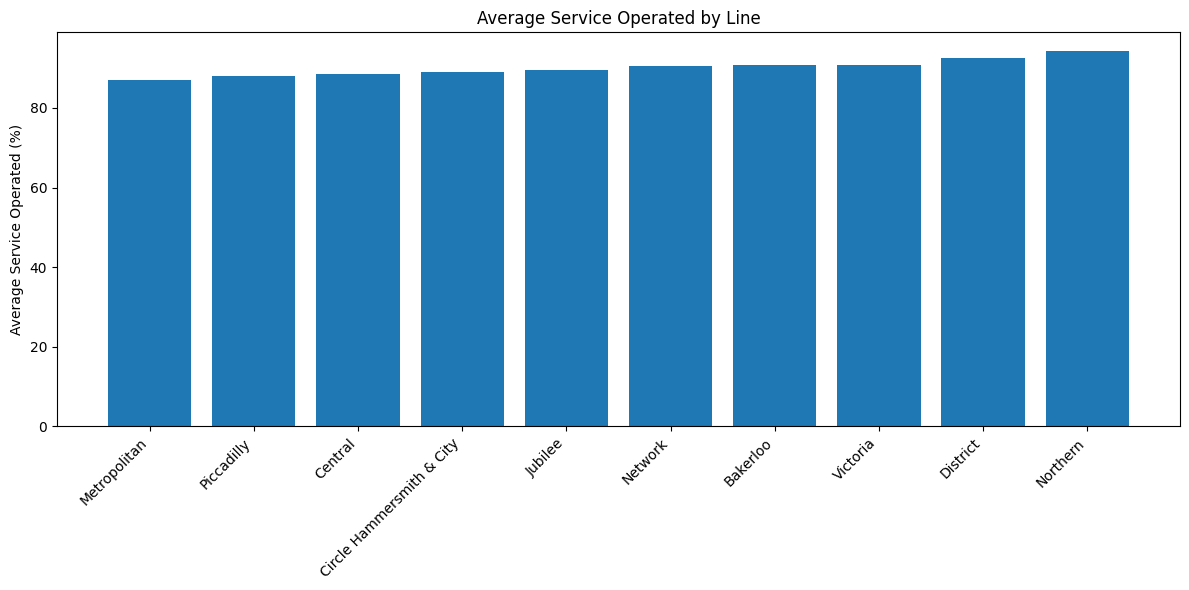

In [9]:
plt.figure(figsize=(12, 6))
plt.bar(
    service_line_summary["Line"],
    service_line_summary["Service Operated for Period - All Week"]
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Average Service Operated (%)")
plt.title("Average Service Operated by Line")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "avg_service_operated_by_line.png")
plt.show()

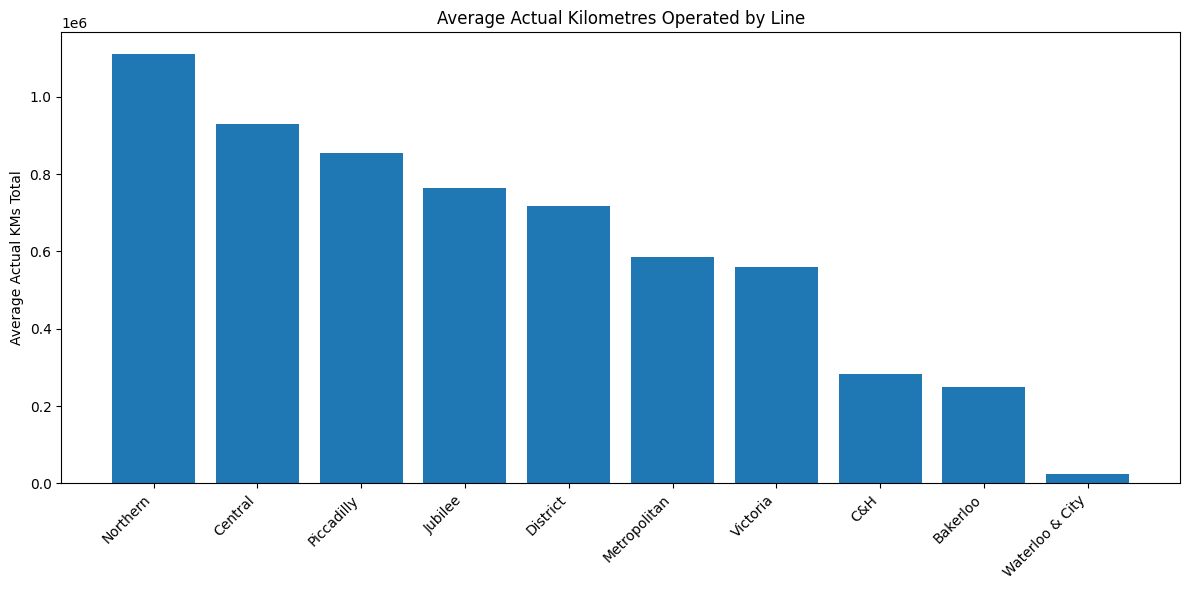

In [11]:
plt.figure(figsize=(12, 6))
plt.bar(
    km_line_summary["Line"],
    km_line_summary["Actual KMs Total"]
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Average Actual KMs Total")
plt.title("Average Actual Kilometres Operated by Line")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "avg_actual_km_by_line.png")
plt.show()

## Step 3: Compare structural centrality with simulated failure impact

This visual shows that station vulnerability is multi-dimensional and cannot be captured by a single graph metric.

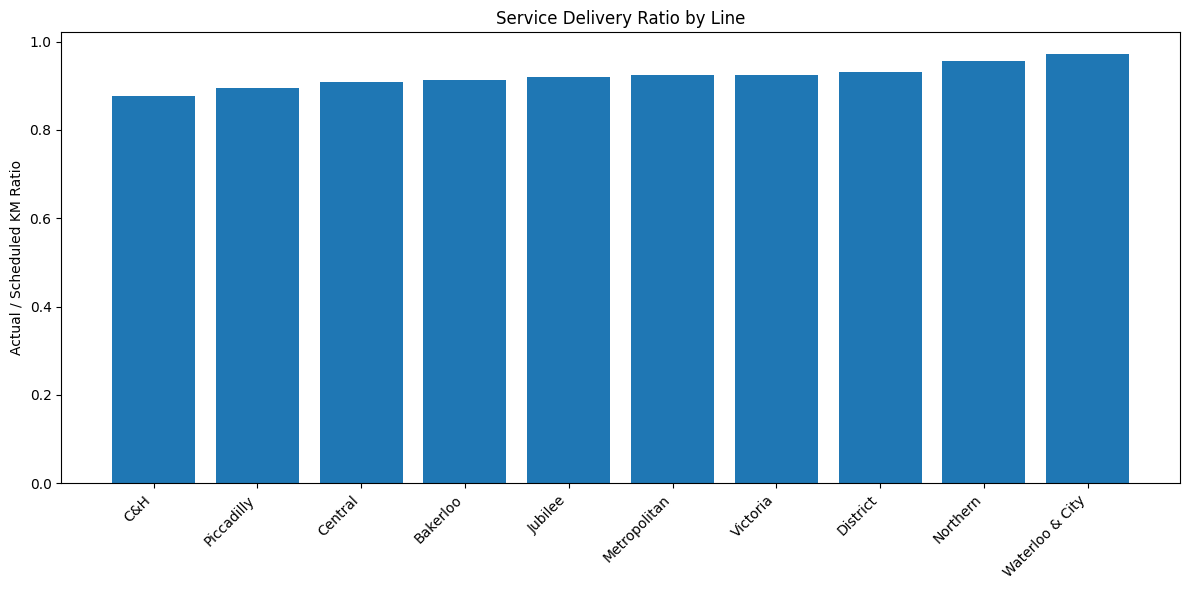

In [12]:
plt.figure(figsize=(12, 6))
plt.bar(
    km_comparison_summary["Line"],
    km_comparison_summary["km_delivery_ratio"]
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Actual / Scheduled KM Ratio")
plt.title("Service Delivery Ratio by Line")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "km_delivery_ratio_by_line.png")
plt.show()

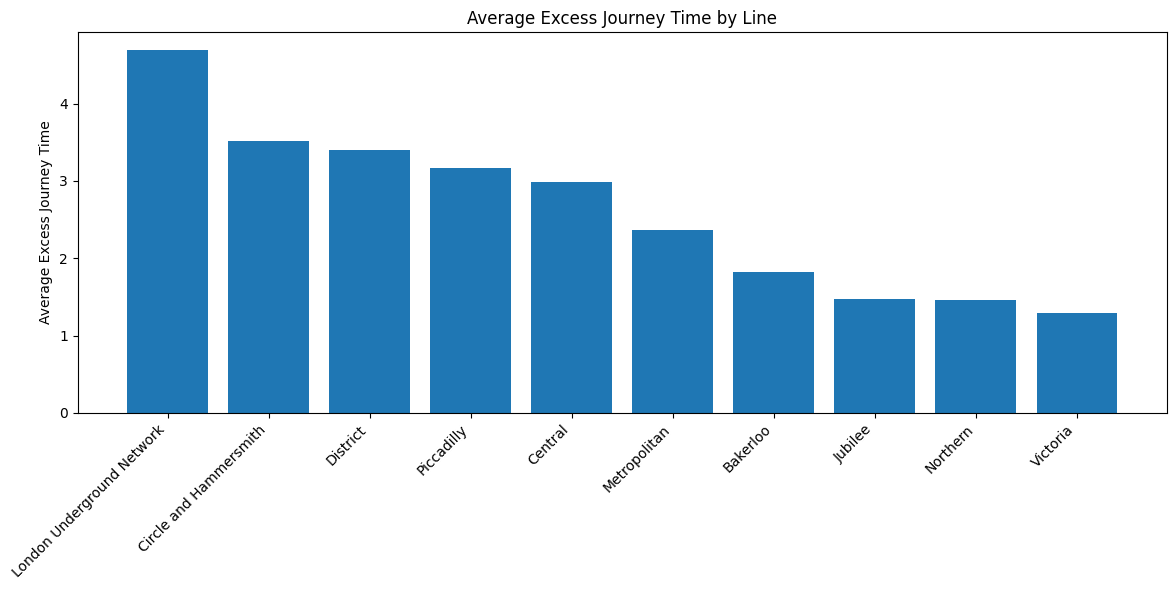

In [13]:
plt.figure(figsize=(12, 6))
plt.bar(
    ejt_line_summary["Line"],
    ejt_line_summary["EJT for Period"]
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Average Excess Journey Time")
plt.title("Average Excess Journey Time by Line")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "avg_excess_journey_time_by_line.png")
plt.show()

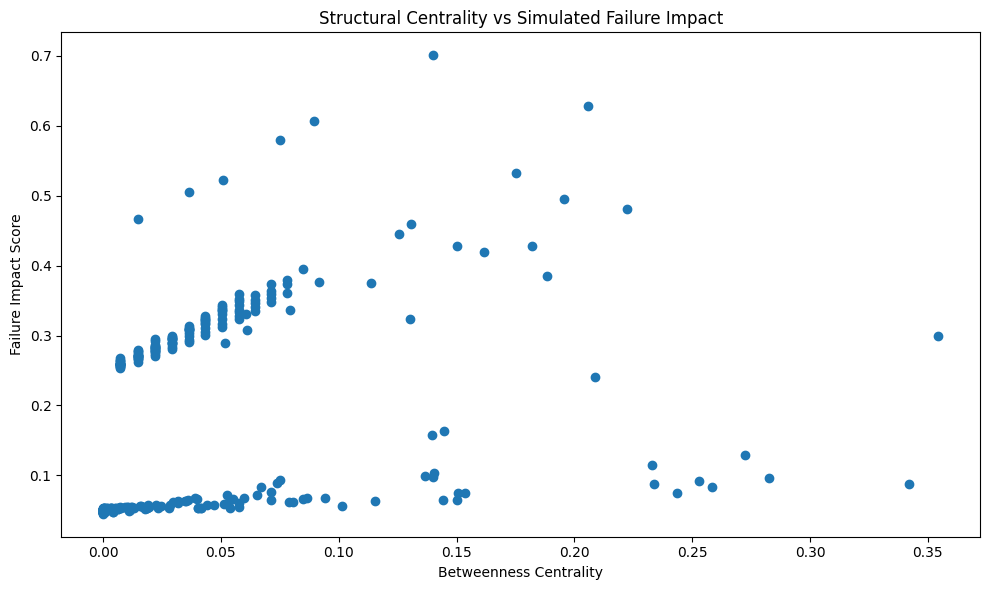

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(
    risk_scores["betweenness_centrality"],
    risk_scores["failure_impact_score"]
)
plt.xlabel("Betweenness Centrality")
plt.ylabel("Failure Impact Score")
plt.title("Structural Centrality vs Simulated Failure Impact")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "centrality_vs_failure_impact.png")
plt.show()

In [15]:
final_station_table = risk_scores[[
    "station_display",
    "propagation_risk_score",
    "failure_impact_score",
    "betweenness_centrality",
    "num_components",
    "avg_shortest_path"
]].head(15)

final_station_table

,station_display,propagation_risk_score,failure_impact_score,betweenness_centrality,num_components,avg_shortest_path
0,Baker Street,0.790000,0.300000,0.354381,1,17.167910
1,Green Park,0.675229,0.087338,0.341879,1,14.429684
2,Earls Court,0.645965,0.628970,0.205972,3,14.673101
3,Kings Cross St. Pancras,0.624664,0.495714,0.195583,2,14.127852
4,Waterloo,0.593848,0.095969,0.282364,1,14.540823
5,Liverpool Street,0.556405,0.129022,0.272424,1,14.966407
6,Stratford,0.524362,0.480642,0.222199,2,13.407044
7,Wembley Park,0.518721,0.428194,0.182102,2,15.541015
8,Bank,0.517697,0.092494,0.252756,1,14.496078
9,Camden Town,0.507684,0.700896,0.139921,3,13.667825


In [16]:
final_station_table.to_csv(PROCESSED_DIR / "final_station_table.csv", index=False)
print("Saved final_station_table.csv")

Saved final_station_table.csv
